# Method 1 — Frangi / Sato Vesselness + Automatic Thresholding

**Pipeline**
```
CT image
→ Frangi or Sato filter (Hessian-based multiscale ridge enhancement)
→ Percentile / Otsu / Adaptive threshold
→ Remove small components
→ Binary mask  (0 = background, 255 = crack)
```

Frangi and Sato filters enhance thin curvilinear structures (cracks) while suppressing blobs and flat regions. This is a *"Hessian-based multiscale curvilinear segmentation baseline."*

## Configuration

In [58]:
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
SAMPLES_DIR = Path("../samples")
OUTPUT_DIR  = Path("output/method1_frangi_sato")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Filter ─────────────────────────────────────────────────────────────────
FILTER = "sato"        # "frangi" | "sato"

# ── Scales ─────────────────────────────────────────────────────────────────
# Probes structures at these pixel radii. Increase upper bound for wider cracks.
SIGMAS = range(1, 4)

# ── Thresholding ───────────────────────────────────────────────────────────
THRESHOLD_METHOD = "percentile"   # "percentile" | "otsu" | "adaptive"
PERCENTILE       = 93.0           # used when THRESHOLD_METHOD == "percentile"
                                  # keep top (100 - PERCENTILE)% of response

# ── Post-processing ────────────────────────────────────────────────────────
MIN_COMPONENT_SIZE = 100          # remove connected components smaller than this (px)

print("Configuration loaded.")

Configuration loaded.


## Imports

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float
from skimage.color import rgb2gray
from skimage.filters import frangi, sato, threshold_otsu, threshold_local
from skimage.morphology import remove_small_objects, binary_closing, disk

print("Imports OK.")

Imports OK.


## Pipeline functions

In [60]:
def load_grayscale(path: Path) -> np.ndarray:
    """Load image as float64 grayscale in [0, 1]."""
    img = io.imread(str(path))
    if img.ndim == 3:
        img = rgb2gray(img)
    return img_as_float(img)


def apply_vesselness(img: np.ndarray) -> np.ndarray:
    """Apply Frangi or Sato filter and return the response map.

    black_ridges=False → detect bright ridges (cracks appear bright in X-ray).
    """
    if FILTER == "frangi":
        return frangi(img, sigmas=SIGMAS, black_ridges=False)
    elif FILTER == "sato":
        return sato(img, sigmas=SIGMAS, black_ridges=False)
    else:
        raise ValueError(f"Unknown filter: {FILTER!r}")


def threshold_response(response: np.ndarray) -> np.ndarray:
    """Convert the vesselness response map to a binary mask.

    The Frangi/Sato response is extremely skewed (most pixels ≈ 0).
    A percentile threshold on the non-zero values is therefore more robust
    than Otsu, which can set the cut-off either too high (empty mask) or
    too low (noisy mask).
    """
    if THRESHOLD_METHOD == "percentile":
        nonzero = response[response > 0]
        if nonzero.size == 0:
            return np.zeros_like(response, dtype=bool)
        thresh = np.percentile(nonzero, PERCENTILE)
        return response > thresh
    elif THRESHOLD_METHOD == "otsu":
        return response > threshold_otsu(response)
    elif THRESHOLD_METHOD == "adaptive":
        thresh_map = threshold_local(response, block_size=91, method="gaussian")
        return response > thresh_map
    else:
        raise ValueError(f"Unknown threshold method: {THRESHOLD_METHOD!r}")


def postprocess(binary: np.ndarray) -> np.ndarray:
    """Remove small noise blobs and lightly close gaps."""
    cleaned = remove_small_objects(binary, min_size=MIN_COMPONENT_SIZE)
    return binary_closing(cleaned, footprint=disk(1))


def save_mask(mask: np.ndarray, out_path: Path) -> None:
    """Save boolean mask as 8-bit PNG (0 = background, 255 = crack)."""
    out_path.parent.mkdir(parents=True, exist_ok=True)
    io.imsave(str(out_path), (mask.astype(np.uint8)) * 255, check_contrast=False)


print("Functions defined.")

Functions defined.


## Run predictions on all samples

In [61]:
exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
images = sorted(p for p in SAMPLES_DIR.iterdir() if p.suffix.lower() in exts)

print(f"Filter      : {FILTER}")
print(f"Threshold   : {THRESHOLD_METHOD}" + (f"  (p={PERCENTILE})" if THRESHOLD_METHOD == "percentile" else ""))
print(f"Output dir  : {OUTPUT_DIR.resolve()}")
print(f"Images      : {len(images)}\n")

for img_path in images:
    print(f"  {img_path.name} ...", end=" ", flush=True)
    img      = load_grayscale(img_path)
    response = apply_vesselness(img)
    binary   = threshold_response(response)
    mask     = postprocess(binary)
    out_path = OUTPUT_DIR / (img_path.stem + "_mask.png")
    save_mask(mask, out_path)
    print(f"-> {out_path.name}")

print("\nDone.")

Filter      : sato
Threshold   : percentile  (p=93.0)
Output dir  : /Users/ramyar/Git/Realistic_Crack/Unsupervised methods/output/method1_frangi_sato
Images      : 12

  front_0263_1A_220kv.png ... -> front_0263_1A_220kv_mask.png
  front_1100_3A_135kv.png ... -> front_1100_3A_135kv_mask.png
  front_1208_3A_220kv.png ... -> front_1208_3A_220kv_mask.png
  front_1210_1B_135kv.png ... -> front_1210_1B_135kv_mask.png
  front_1274_4A_135kv.png ... -> front_1274_4A_135kv_mask.png
  front_1629_1B_220kv.png ... -> front_1629_1B_220kv_mask.png
  front_1688_2B_220kv.png ... -> front_1688_2B_220kv_mask.png
  front_1851_2A_220kv.png ... -> front_1851_2A_220kv_mask.png
  front_2203_4A_220kv.png ... -> front_2203_4A_220kv_mask.png
  front_2265_2B_135kv.png ... -> front_2265_2B_135kv_mask.png
  front_2402_2A_135kv.png ... -> front_2402_2A_135kv_mask.png
  front_4292_6.png ... -> front_4292_6_mask.png

Done.


## Visual inspection — image | response map | binary mask

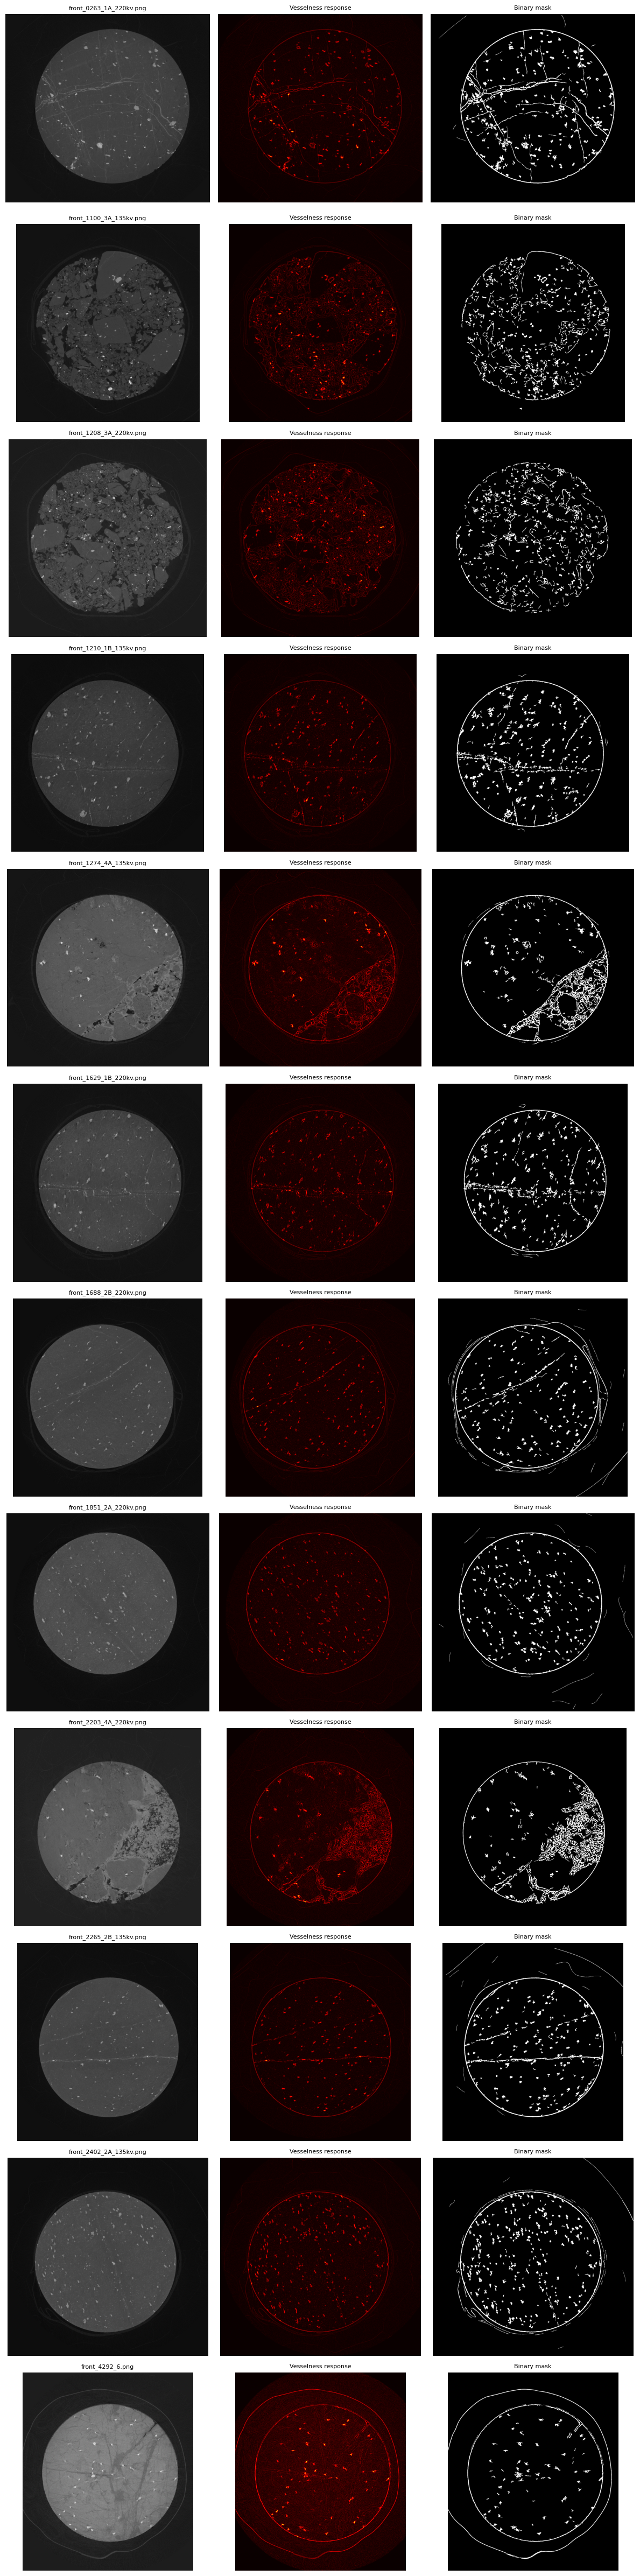

In [62]:
fig, axes = plt.subplots(len(images), 3, figsize=(12, 4 * len(images)))
if len(images) == 1:
    axes = [axes]

for ax_row, img_path in zip(axes, images):
    img      = load_grayscale(img_path)
    response = apply_vesselness(img)
    binary   = threshold_response(response)
    mask     = postprocess(binary)

    ax_row[0].imshow(img, cmap="gray")
    ax_row[0].set_title(img_path.name, fontsize=8)
    ax_row[0].axis("off")

    ax_row[1].imshow(response, cmap="hot")
    ax_row[1].set_title("Vesselness response", fontsize=8)
    ax_row[1].axis("off")

    ax_row[2].imshow(mask, cmap="gray")
    ax_row[2].set_title("Binary mask", fontsize=8)
    ax_row[2].axis("off")

plt.tight_layout()
plt.show()